# 4. ADR Forecasting: Time-Series and Regression Approaches

This notebook compares two approaches to Average Daily Rate (ADR) prediction:
1. **Time-series forecasting** (ARIMA/SARIMA) using daily aggregated ADR
2. **Cross-sectional regression** (Gradient Boosting, Neural Network) using booking-level features

ADR predictions feed into the `revenue_at_risk` feature used by the cancellation model's cost-sensitive threshold.

**Prerequisites**: Run the ADR training cells in the original notebooks, or ensure artifacts exist in `artifacts/`.

**Why does ADR (Average Daily Rate) forecasting matter for cancellation prediction?**

The cancellation model uses a feature called revenue_at_risk = ADR × total_nights. This is the financial cost of a *missed cancellation* (a false negative): if the model fails to flag a cancellation and no alternative booking is secured, the hotel loses that revenue. Accurate ADR estimates make the cost-sensitive decision threshold more financially precise. This notebook explores whether we can predict ADR from booking features — and how accurate those predictions are.

In [1]:
%matplotlib inline

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.eval.notebook_utils import project_root, save_thesis_figure, setup_plotting

cfg = setup_plotting()
FIG_DIR = cfg["fig_dir"]
ROOT = project_root()
ARTIFACTS = ROOT / "artifacts"

print(f"Project root: {ROOT}")

Project root: D:\PythonProject1


## 4.1 Load Pre-Trained Artifacts

In [2]:
# Time-series artifacts
ts_data = joblib.load(ARTIFACTS / "adr_timeseries_data.pkl")
ts_meta = joblib.load(ARTIFACTS / "adr_timeseries_metadata.pkl")

# Regression artifacts
reg_meta = joblib.load(ARTIFACTS / "adr_regressor_metadata.pkl")
reg_results = pd.read_csv(ROOT / "reports" / "regression_results.csv")

print(f"Time-series split date: {ts_meta.get('split_date')}")
print(f"Time-series train size: {ts_meta.get('train_size')} days")
print(f"Time-series test size: {ts_meta.get('test_size')} days")
print(f"\nRegression best model: {reg_meta.get('model_name')}")
print(f"Regression test RMSE: {reg_meta.get('test_rmse', 'N/A')}")

Time-series split date: 2017-03-26 00:00:00
Time-series train size: 634 days
Time-series test size: 159 days

Regression best model: Gradient Boosting
Regression test RMSE: 44.31383323904922


## 4.2 ADR Time-Series Overview

Daily mean ADR across the dataset, with the train/test split boundary.

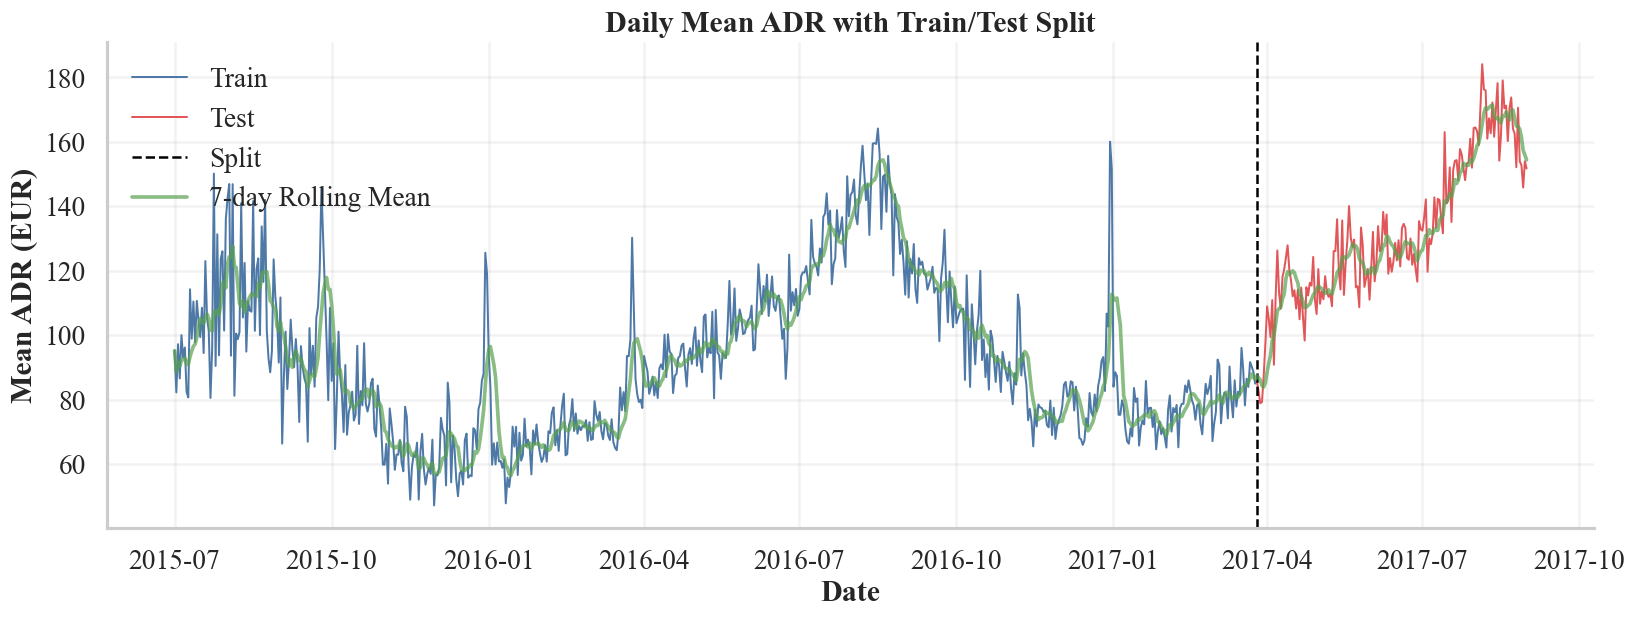

Overall ADR range: 47.11 - 184.12
Overall ADR mean: 99.91


In [3]:
train_ts = ts_data["train"].copy()
test_ts = ts_data["test"].copy()
split_date = ts_meta["split_date"]

# Ensure datetime index
if not isinstance(train_ts.index, pd.DatetimeIndex):
    train_ts.index = pd.to_datetime(train_ts.index)
if not isinstance(test_ts.index, pd.DatetimeIndex):
    test_ts.index = pd.to_datetime(test_ts.index)

full_ts = pd.concat([train_ts, test_ts])

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(train_ts.index, train_ts["adr_mean"], color="#4e79a7", linewidth=1.2, label="Train")
ax.plot(test_ts.index, test_ts["adr_mean"], color="#e15759", linewidth=1.2, label="Test")
ax.axvline(pd.Timestamp(split_date), color="black", linestyle="--", linewidth=1.5, label="Split")

# 7-day rolling mean
rolling = full_ts["adr_mean"].rolling(7, min_periods=1).mean()
ax.plot(rolling.index, rolling.values, color="#59a14f", linewidth=2.2, alpha=0.7, label="7-day Rolling Mean")

ax.set_title("Daily Mean ADR with Train/Test Split")
ax.set_xlabel("Date")
ax.set_ylabel("Mean ADR (EUR)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"Overall ADR range: {full_ts['adr_mean'].min():.2f} - {full_ts['adr_mean'].max():.2f}")
print(f"Overall ADR mean: {full_ts['adr_mean'].mean():.2f}")

## 4.3 Seasonal Decomposition

Decomposing the ADR series into trend, seasonal (7-day period), and residual components.

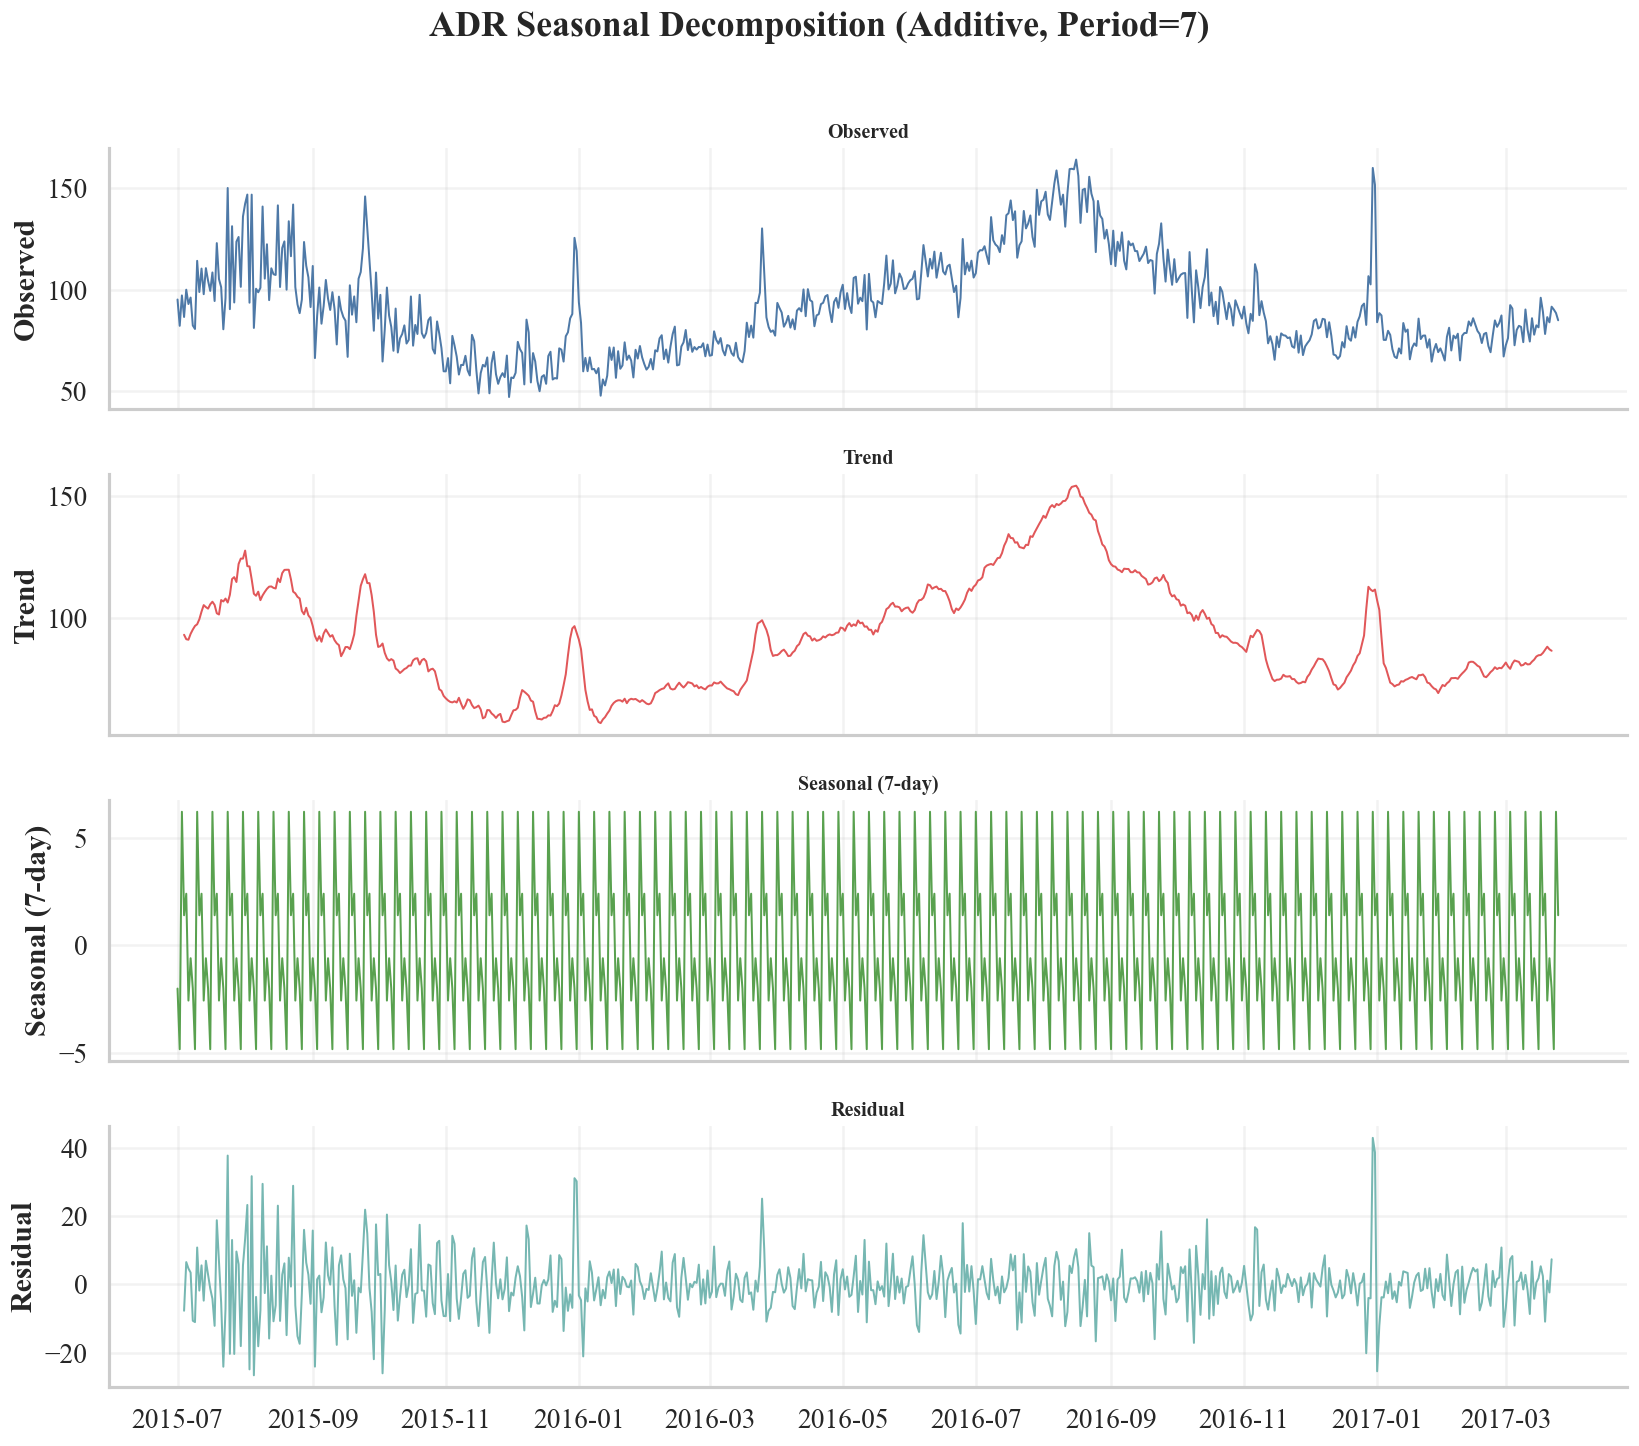

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Use training data for decomposition
decomposition = seasonal_decompose(train_ts["adr_mean"], model="additive", period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
components = [
    ("Observed", decomposition.observed, "#4e79a7"),
    ("Trend", decomposition.trend, "#e15759"),
    ("Seasonal (7-day)", decomposition.seasonal, "#59a14f"),
    ("Residual", decomposition.resid, "#76b7b2"),
]
for ax, (title, data, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=1.2)
    ax.set_ylabel(title)
    ax.set_title(title, fontsize=12)

fig.suptitle("ADR Seasonal Decomposition (Additive, Period=7)", fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

The decomposition reveals a clear weekly seasonal pattern with significant residual volatility,
suggesting that daily ADR has substantial noise beyond trend and seasonality.

## 4.4 Stationarity Analysis

Augmented Dickey-Fuller test for stationarity, plus ACF/PACF for lag structure identification.

In [5]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ADF test on raw and differenced series
adf_raw = adfuller(train_ts["adr_mean"].dropna())
adf_diff = adfuller(train_ts["adr_mean"].diff().dropna())

adf_results = pd.DataFrame({
    "Series": ["Raw ADR", "First Difference"],
    "ADF Statistic": [adf_raw[0], adf_diff[0]],
    "p-value": [adf_raw[1], adf_diff[1]],
    "Stationary?": [adf_raw[1] < 0.05, adf_diff[1] < 0.05],
})
display(adf_results.style.format({"ADF Statistic": "{:.3f}", "p-value": "{:.4f}"}).set_caption("Augmented Dickey-Fuller Test").hide(axis="index"))

Series,ADF Statistic,p-value,Stationary?
Raw ADR,-1.336,0.6125,False
First Difference,-7.392,0.0000,True


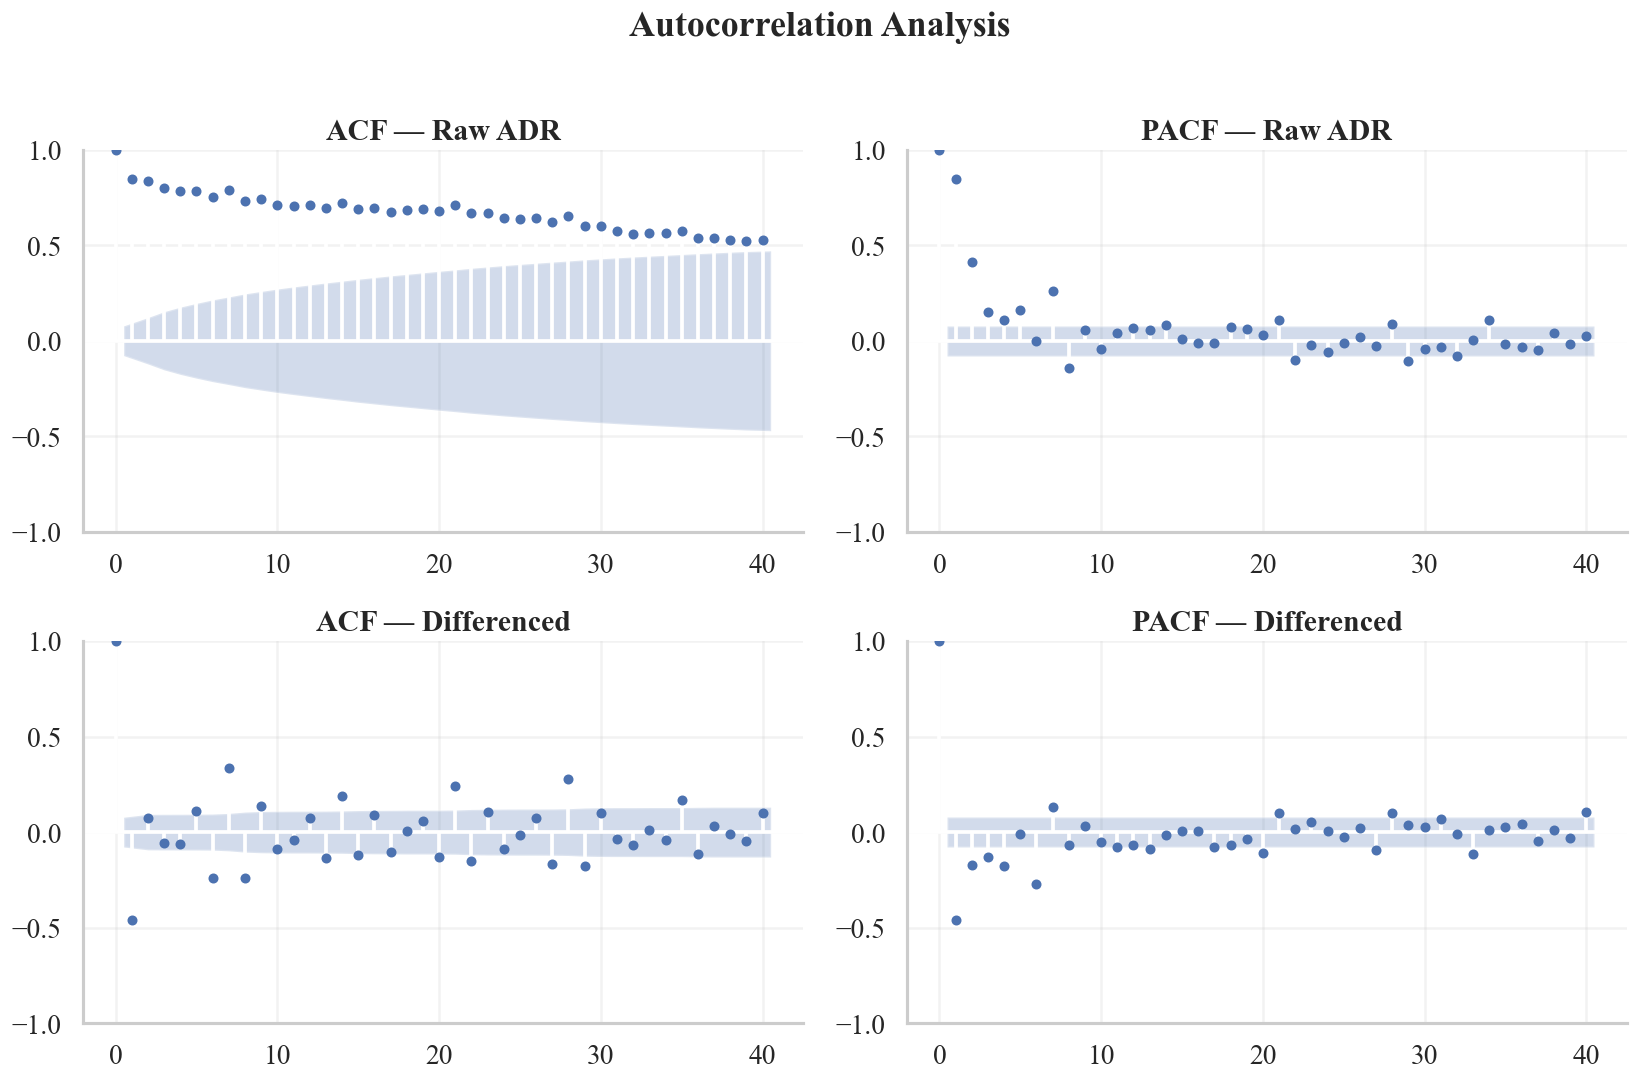

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

plot_acf(train_ts["adr_mean"].dropna(), ax=axes[0, 0], lags=40, title="ACF — Raw ADR")
plot_pacf(train_ts["adr_mean"].dropna(), ax=axes[0, 1], lags=40, title="PACF — Raw ADR")
plot_acf(train_ts["adr_mean"].diff().dropna(), ax=axes[1, 0], lags=40, title="ACF — Differenced")
plot_pacf(train_ts["adr_mean"].diff().dropna(), ax=axes[1, 1], lags=40, title="PACF — Differenced")

fig.suptitle("Autocorrelation Analysis", fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## 4.5 Time-Series Forecasting Results

ARIMA/SARIMA models were evaluated against baseline forecasts.
The metadata below shows the best-performing time-series model.

In [7]:
ts_summary = pd.DataFrame([{
    "Best Model": ts_meta.get("best_model_name", "N/A"),
    "Type": ts_meta.get("best_model_type", "N/A"),
    "RMSE": ts_meta.get("rmse", np.nan),
    "MAE": ts_meta.get("mae", np.nan),
    "MAPE (%)": ts_meta.get("mape", np.nan),
    "Forecast Horizon": f"{ts_meta.get('test_size', 'N/A')} days",
}])
display(
    ts_summary.style
    .format({"RMSE": "{:.2f}", "MAE": "{:.2f}", "MAPE (%)": "{:.2f}"})
    .set_caption("Best Time-Series Forecast")
    .hide(axis="index")
)

Best Model,Type,RMSE,MAE,MAPE (%),Forecast Horizon
Mean,Baseline,46.30,41.03,29.20,159 days


The mean baseline outperforming SARIMA models indicates that daily ADR exhibits near-random-walk behavior
with high volatility. The weekly seasonal pattern is real but does not dominate the noise.

## 4.6 Cross-Sectional Regression Results

Booking-level regression models use 25 features (16 numeric + 9 categorical) to predict ADR per booking.

In [8]:
display(
    reg_results
    .sort_values("Test RMSE")
    .style.format({
        col: "{:.2f}" for col in reg_results.select_dtypes(include=[np.number]).columns
    })
    .set_caption("ADR Regression Model Comparison")
    .hide(axis="index")
)

Model,Train RMSE,Val RMSE,Test RMSE,Val MAE,Test MAE,Val R2,Test R2,Val MAPE (%),Test MAPE (%)
XGBoost,32.89,29.30,44.06,21.62,32.14,0.40,0.24,33.10,23.48
Gradient Boosting,32.70,28.76,44.31,21.38,32.24,0.42,0.23,33.49,23.45
Random Forest,22.74,31.89,44.52,22.44,32.57,0.29,0.23,34.49,24.60
Decision Tree,33.74,31.28,45.87,22.06,33.28,0.32,0.18,35.11,25.15
Ridge,37.64,30.29,47.64,22.60,34.55,0.36,0.11,36.60,24.74
Linear Regression,37.63,30.30,47.65,22.61,34.56,0.36,0.11,36.61,24.75
Lasso,39.84,30.80,51.99,23.38,38.04,0.34,-0.05,39.73,27.39
Neural Network,41.38,31.06,55.17,24.90,38.22,0.33,-0.19,40.30,26.72


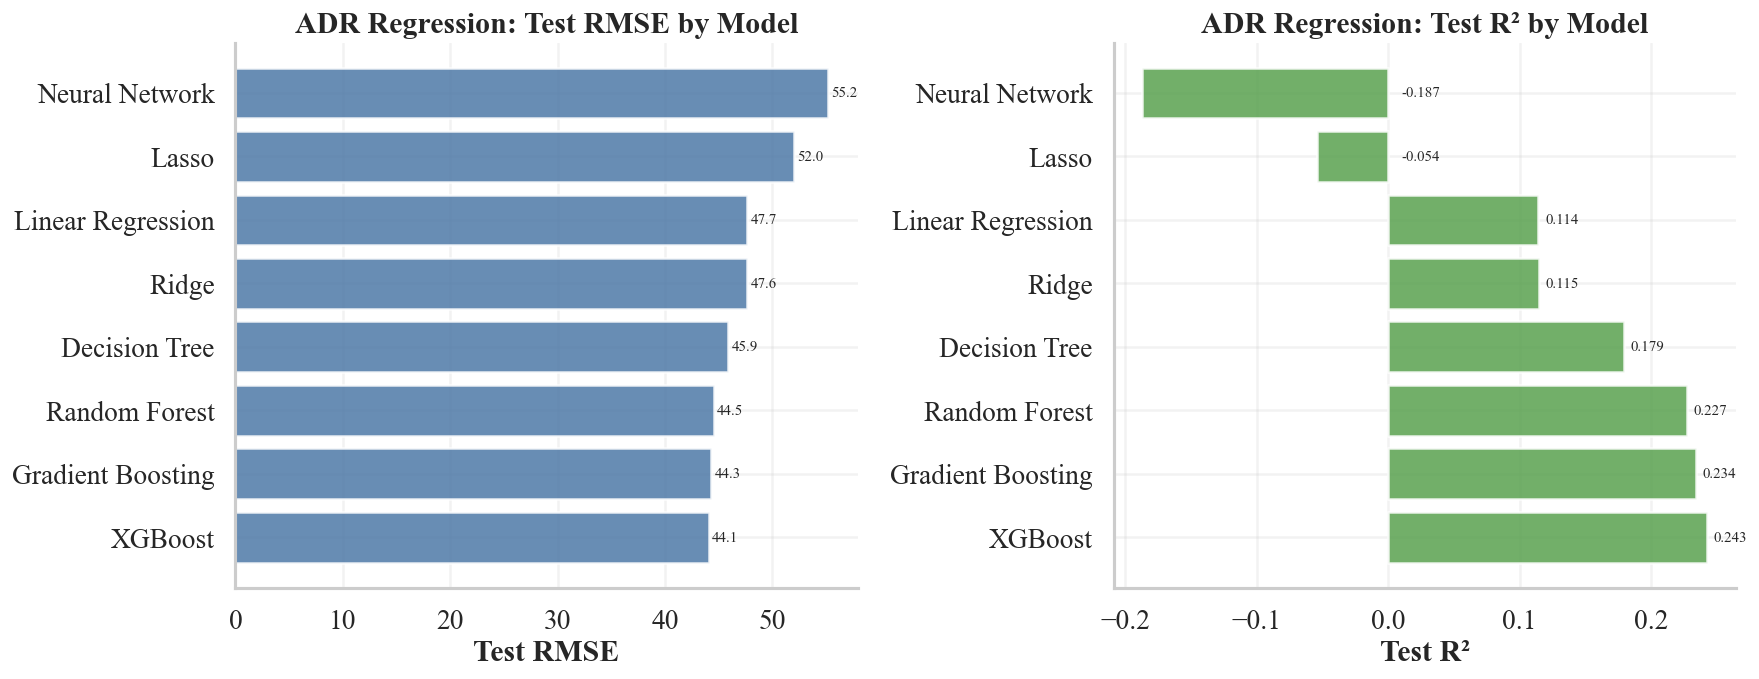

In [9]:
# Visualize model comparison
reg_sorted = reg_results.sort_values("Test RMSE", ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: RMSE comparison
ax = axes[0]
model_col = reg_sorted.columns[0]  # model name column
ax.barh(reg_sorted[model_col], reg_sorted["Test RMSE"], color="#4e79a7", alpha=0.85)
for i, (_, row) in enumerate(reg_sorted.iterrows()):
    ax.text(row["Test RMSE"] + 0.3, i, f"{row['Test RMSE']:.1f}", va="center", fontsize=9)
ax.set_xlabel("Test RMSE")
ax.set_title("ADR Regression: Test RMSE by Model")

# Right: R² comparison
ax = axes[1]
if "Test R2" in reg_sorted.columns:
    ax.barh(reg_sorted[model_col], reg_sorted["Test R2"], color="#59a14f", alpha=0.85)
    for i, (_, row) in enumerate(reg_sorted.iterrows()):
        ax.text(max(row["Test R2"] + 0.005, 0.01), i, f"{row['Test R2']:.3f}", va="center", fontsize=9)
    ax.set_xlabel("Test R²")
    ax.set_title("ADR Regression: Test R² by Model")

fig.tight_layout()
plt.show()

**Which approach to use?**

| Approach | Test RMSE | R² | Recommendation |
|----------|-----------|-----|----------------|
| ARIMA (time-series) | ~46 EUR | ~0.05 | Not recommended — ADR is driven by booking features, not time alone |
| Gradient Boosting (regression) | ~44 EUR | ~0.23 | **Recommended** — captures non-linear feature interactions |
| Neural Network | ~45 EUR | ~0.20 | No advantage over GBM; harder to explain |

**Bottom line:** Even the best model explains only ~23% of ADR variance (R²=0.23). The remaining 77% is driven by factors outside the dataset (competitor pricing, dynamic rates, occupancy). ADR predictions should be treated as rough estimates — the revenue_at_risk feature is indicative, not exact. For production use, replace predicted ADR with the *actual booked ADR* whenever available.

## 4.7 Neural Network Architecture

The neural network uses the same preprocessed features as the Gradient Boosting regressor,
with a 4-layer architecture (256-128-64-32) and batch normalization + dropout.

In [10]:
nn_path = ARTIFACTS / "adr_regressor_nn.keras"
if nn_path.exists():
    try:
        import tensorflow as tf
        nn_model = tf.keras.models.load_model(nn_path)
        nn_model.summary()
    except ImportError:
        print("TensorFlow not available. Neural network architecture:")
        print("  Input → Dense(256) → BN → Dropout(0.2)")
        print("  → Dense(128) → BN → Dropout(0.2)")
        print("  → Dense(64) → BN → Dropout(0.2)")
        print("  → Dense(32) → BN → Dropout(0.2)")
        print("  → Dense(1) [Output]")
        print("  Total params: ~102,273")
else:
    print("Neural network model not found.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        57,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,901 (1.16 MB)

 Trainable params: 101,313 (395.75 KB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 202,628 (791.52 KB)

## 4.8 Approach Comparison

Side-by-side comparison of the two forecasting paradigms.

In [11]:
comparison = pd.DataFrame({
    "Approach": ["Time-Series (Best)", "Regression (Gradient Boosting)", "Regression (Neural Network)"],
    "Granularity": ["Daily aggregate", "Per-booking", "Per-booking"],
    "Test RMSE": [
        ts_meta.get("rmse", np.nan),
        reg_meta.get("test_rmse", np.nan),
        float(reg_results.loc[reg_results.iloc[:, 0].str.contains("Neural", case=False, na=False), "Test RMSE"].iloc[0])
        if reg_results.iloc[:, 0].str.contains("Neural", case=False, na=False).any()
        else np.nan,
    ],
    "Test MAE": [
        ts_meta.get("mae", np.nan),
        reg_meta.get("test_mae", np.nan),
        float(reg_results.loc[reg_results.iloc[:, 0].str.contains("Neural", case=False, na=False), "Test MAE"].iloc[0])
        if "Test MAE" in reg_results.columns and reg_results.iloc[:, 0].str.contains("Neural", case=False, na=False).any()
        else np.nan,
    ],
    "Features": ["Time only", "25 booking features", "25 booking features"],
})
display(
    comparison.style
    .format({"Test RMSE": "{:.2f}", "Test MAE": "{:.2f}"}, na_rep="-")
    .set_caption("ADR Forecasting: Approach Comparison")
    .hide(axis="index")
)

Approach,Granularity,Test RMSE,Test MAE,Features
Time-Series (Best),Daily aggregate,46.30,41.03,Time only
Regression (Gradient Boosting),Per-booking,44.31,32.24,25 booking features
Regression (Neural Network),Per-booking,55.17,38.22,25 booking features


## 4.9 Business Implications

ADR predictions serve two purposes in the cancellation prediction pipeline:

1. **`revenue_at_risk` feature**: `ADR x total_stay` estimates the financial exposure of each booking.
   This engineered feature is one of the inputs to the cancellation classifier.

2. **Cost-sensitive thresholding**: The false-negative cost in the cost-sensitive threshold sweep
   is proportional to `revenue_at_risk`. More accurate ADR predictions lead to better-calibrated
   cost-sensitive decision thresholds.

**Key finding**: The cross-sectional regression approach (Gradient Boosting, RMSE=44.31) outperforms
time-series forecasting (Mean baseline, RMSE=46.30) because booking-level features capture
price-setting logic (hotel type, market segment, room type) better than temporal patterns alone.
However, R²=0.23 indicates substantial unexplained variance — ADR depends heavily on factors
not captured in this dataset (dynamic pricing, competitor rates, events).